# Data Exploration and Preprocessing:

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df_cancer = pd.read_csv('dados/cancer_medicine_data.csv')

# Display first five rows 
df_cancer.head(10)

,cancer_type,age,gender,tumor_size,stage,marker_level,medicine,response_rate,outcome
0,breast,61,Male,6.763762,2.0,87.590492,Drug C,0.698740,1.0
1,prostate,46,Male,2.976943,2.0,136.268355,Drug B,0.615172,1.0
2,prostate,63,Male,8.635724,1.0,76.478761,Drug A,0.392179,0.0
3,lung,66,Male,7.968916,4.0,72.729631,Drug A,0.743992,1.0
4,breast,65,Male,5.270337,1.0,10.680070,Drug B,0.495621,0.0
5,breast,70,Male,6.886862,1.0,95.340288,Drug A,0.569257,1.0
6,breast,68,Female,4.417239,2.0,6.022694,Drug C,0.462286,0.0
7,prostate,64,Female,3.446563,3.0,48.159290,Drug B,0.420541,0.0
8,lung,59,Male,4.621975,2.0,66.632578,Drug A,0.408373,0.0
9,prostate,43,Female,5.951707,3.0,51.458186,Drug A,0.359137,0.0


# Histogram 

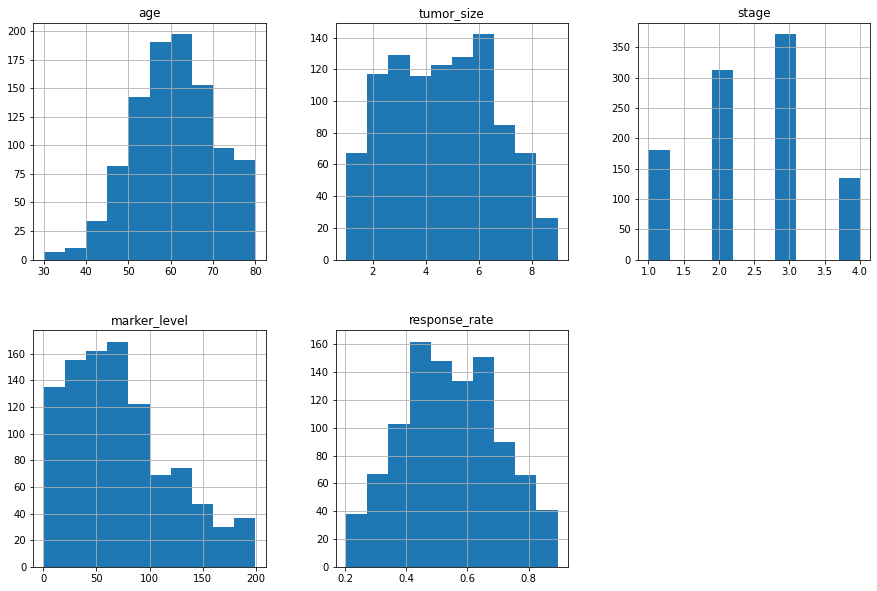

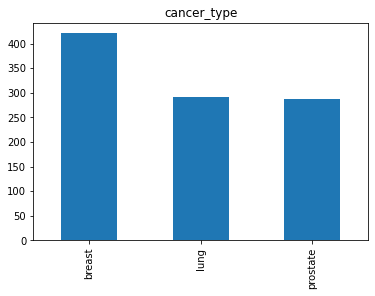

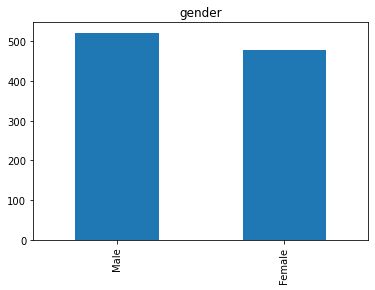

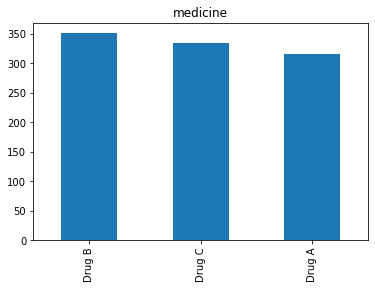

In [2]:
import matplotlib.pyplot as plt

# Histogram plot
numeric_columns = ['age', 'tumor_size', 'stage', 'marker_level', 'response_rate']
df_cancer[numeric_columns].hist(bins=10, figsize=(15, 10), layout=(2, 3))

categorical_columns = ['cancer_type', 'gender', 'medicine']
for col in categorical_columns:
    plt.figure()
    df_cancer[col].value_counts().plot(kind='bar', title=col)

plt.show()

# Standard deviation

In [3]:
# computing the standard deviation 
std_values = df_cancer[['age', 'tumor_size', 'stage', 'marker_level', 'response_rate']].std()
print(std_values)

age               9.722573
tumor_size        1.935605
stage             0.938766
marker_level     48.121372
response_rate     0.157367
dtype: float64


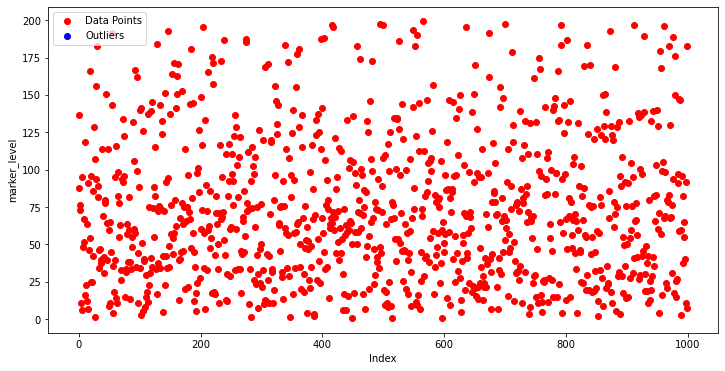

In [4]:
# Outlier detection for marker_level using Tukey's method
column = 'marker_level'
Q1 = df_cancer[column].quantile(0.25)
Q3 = df_cancer[column].quantile(0.75)
IQR = Q3 - Q1
limIn = Q1 - (IQR * 1.5)
limSp = Q3 + (IQR * 1.5)
idx = np.where((df_cancer[column] < limIn) | (df_cancer[column] > limSp))[0]

# Plot data with outliers highlighted
plt.figure(figsize=(12, 6))

# Scatter plot of all data points
plt.scatter(df_cancer.index, df_cancer[column], color='red', label='Data Points')

# Highlight outliers
plt.scatter(idx, df_cancer.iloc[idx][column], color='blue', label='Outliers')

plt.xlabel('Index')
plt.ylabel(column)
plt.legend()
plt.show()

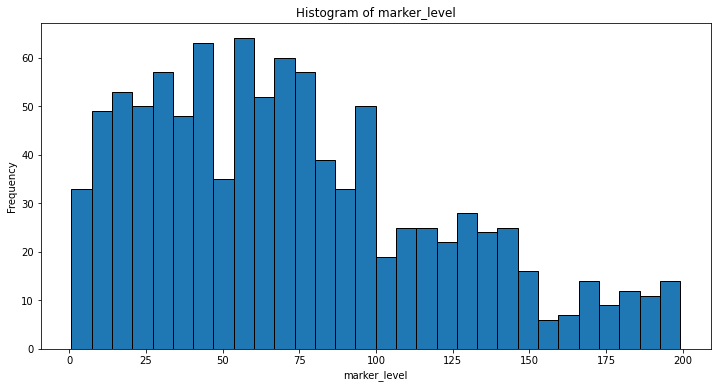

In [5]:
# Histogram of marker level frequency 
plt.figure(figsize=(12, 6))
plt.hist(df_cancer[column], bins=30, edgecolor='k')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title('Histogram of ' + column)
plt.show()

# Encoding categorical variables

In [6]:
# Add patient_id column
df_cancer['patient_id'] = range(1, len(df_cancer) + 1)

# Set patient_id as the index
df_cancer.set_index('patient_id', inplace=True)
df_cancer.head(10)

,cancer_type,age,gender,tumor_size,stage,marker_level,medicine,response_rate,outcome
patient_id,,,,,,,,,
1,breast,61,Male,6.763762,2.0,87.590492,Drug C,0.698740,1.0
2,prostate,46,Male,2.976943,2.0,136.268355,Drug B,0.615172,1.0
3,prostate,63,Male,8.635724,1.0,76.478761,Drug A,0.392179,0.0
4,lung,66,Male,7.968916,4.0,72.729631,Drug A,0.743992,1.0
5,breast,65,Male,5.270337,1.0,10.680070,Drug B,0.495621,0.0
6,breast,70,Male,6.886862,1.0,95.340288,Drug A,0.569257,1.0
7,breast,68,Female,4.417239,2.0,6.022694,Drug C,0.462286,0.0
8,prostate,64,Female,3.446563,3.0,48.159290,Drug B,0.420541,0.0
9,lung,59,Male,4.621975,2.0,66.632578,Drug A,0.408373,0.0


In [7]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
lb = LabelEncoder()

# Select all object columns
objList = df_cancer.select_dtypes(include="object").columns

# Apply LabelEncoder to each object column
for col in objList:
    df_cancer[col] = lb.fit_transform(df_cancer[col].astype(str))

# Ensure all data is numeric
df_cancer = df_cancer.apply(pd.to_numeric, errors='coerce')

# Drop rows with any missing values
df_cancer_encoded = df_cancer.dropna()

pd.DataFrame(df_cancer_encoded)

,cancer_type,age,gender,tumor_size,stage,marker_level,medicine,response_rate,outcome
patient_id,,,,,,,,,
1,0,61,1,6.763762,2.0,87.590492,2,0.698740,1.0
2,2,46,1,2.976943,2.0,136.268355,1,0.615172,1.0
3,2,63,1,8.635724,1.0,76.478761,0,0.392179,0.0
4,1,66,1,7.968916,4.0,72.729631,0,0.743992,1.0
5,0,65,1,5.270337,1.0,10.680070,1,0.495621,0.0
...,...,...,...,...,...,...,...,...,...
996,0,46,0,2.960768,1.0,40.519714,2,0.522970,1.0
997,2,53,1,1.581083,3.0,91.426321,2,0.402408,0.0
998,0,59,1,5.959306,1.0,10.745055,1,0.725414,1.0


# Model Selection and Training

In [8]:
from sklearn.model_selection import train_test_split

# Divide the data into independent variables (X) and dependent variable (y)
X = df_cancer_encoded.iloc[:,:-1].values
y = df_cancer_encoded.iloc[:,-1].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Decision Trees

In [9]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

# Train the model
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [10]:
# model score with train data
tree_clf.score(X_test, y_test)

1.0

In [11]:
# model score with test data
tree_clf.score(X_train, y_train)

1.0

## Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
# model score with train data
model.score(X_train, y_train)

0.98625

In [14]:
# model score with test data
model.score(X_test, y_test)

0.975

### Model Evaluation

Accuracy: 0.975
Confusion Matrix:
[[ 86   2]
 [  3 109]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97        88
         1.0       0.98      0.97      0.98       112

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



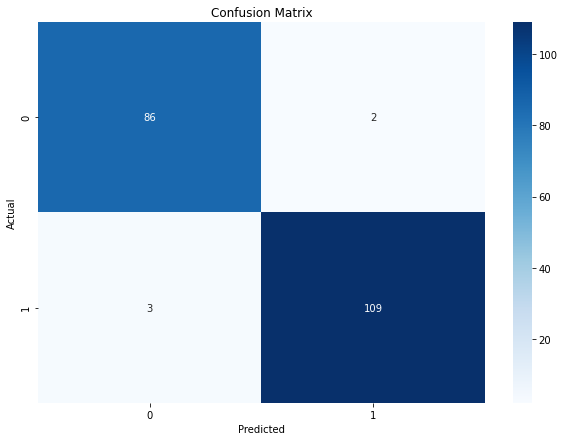

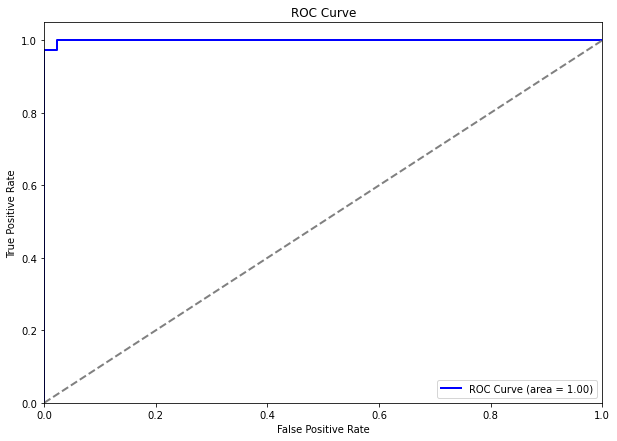

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import seaborn as sns

# Make prediction
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display the results
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

# Plot the Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


##  AUC and CV

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Define the number of folds for cross-validation
n_folds = 5

# Use AUC as the evaluation metric for cross-validation
auc_scorer = make_scorer(roc_auc_score)

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=n_folds, scoring=auc_scorer)

# Display the results
print(f'AUC scores for each fold: {cv_scores}')
print(f'Mean AUC: {cv_scores.mean()}')
print(f'Standard Deviation of AUC: {cv_scores.std()}')

AUC scores for each fold: [0.9691072  0.9854289  0.95705901 0.9751642  0.96325944]
Mean AUC: 0.9700037487324566
Standard Deviation of AUC: 0.009781833143374722


## Feature Engineering

### PolynomialFeatures

In [17]:
from sklearn.preprocessing import PolynomialFeatures

# Make a copy of the cancer DataFrame
df_cancer_poly = df_cancer.copy()

# Separate independent and dependent variables
X = df_cancer_poly.drop(columns=['outcome'])
y = df_cancer_poly['outcome']

# Create PolynomialFeatures with degree 2 and interaction only
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

# Transform the data
X_poly = poly.fit_transform(X)

# Get the names of the new features
try:
    feature_names = poly.get_feature_names_out(X.columns)
except AttributeError:
    feature_names = poly.get_feature_names(X.columns)

# Create a new DataFrame with the interaction features
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

# Display some of the new features
print(X_poly_df.head())

   cancer_type   age  gender  tumor_size  stage  marker_level  medicine  \
0          0.0  61.0     1.0    6.763762    2.0     87.590492       2.0   
1          2.0  46.0     1.0    2.976943    2.0    136.268355       1.0   
2          2.0  63.0     1.0    8.635724    1.0     76.478761       0.0   
3          1.0  66.0     1.0    7.968916    4.0     72.729631       0.0   
4          0.0  65.0     1.0    5.270337    1.0     10.680070       1.0   

   response_rate  cancer_type age  cancer_type gender  ...  tumor_size stage  \
0       0.698740              0.0                 0.0  ...         13.527524   
1       0.615172             92.0                 2.0  ...          5.953886   
2       0.392179            126.0                 2.0  ...          8.635724   
3       0.743992             66.0                 1.0  ...         31.875663   
4       0.495621              0.0                 0.0  ...          5.270337   

   tumor_size marker_level  tumor_size medicine  tumor_size response

In [50]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)

# Make predictions and calculate the AUC
y_pred = model2.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f'AUC: {auc}')

AUC: 0.9993912337662337


# Prediction and Interpretation:

In [47]:
print("1 for Male or 0 for Female.")
print("\n1 0 for Breast, 1 for Lung, 2 for Prostate.")
print("\n1 0 for Drug A, 1 for Drug B, 2 for Drug C.")

1 for Male or 0 for Female.

1 0 for Breast, 1 for Lung, 2 for Prostate.

1 0 for Drug A, 1 for Drug B, 2 for Drug C.


In [49]:
cancer_type = input("Enter the patient's cancer type:")
age = input("Enter the patient's age:")
gender = input("Enter the patient's gender:")
tumor_size = input("Enter the patient's tumor size:")
stage = input("Enter the patient's cancer stage:") 
marker_level = input("Enter the patient's cancer marker level:")
medicine = input("Enter the patient's medicine:")
response_rate = input("Enter the patient's response rate:")

# Create a dictionary with patient data
data = {
    'cancer_type': [cancer_type],
    'age': [age],
    'gender': [gender],
    'tumor_size': [tumor_size],
    'stage': [stage],
    'marker_level': [marker_level],
    'medicine': [medicine],
    'response_rate': [response_rate]
}

data_pred = pd.DataFrame(data)

# Supposed array of predicted probabilities
prediction_probabilities = model.predict_proba(data_pred)

# Extract the probabilities
prob_failure = prediction_probabilities[0, 0]
prob_success = prediction_probabilities[0, 1]

# Display the probabilities clearly
print(f"Possibility of the medicine not working: {prob_failure * 100:.2f}%")
print(f"Possibility of the medicine being successful: {prob_success * 100:.2f}%")


KeyboardInterrupt: Interrupted by user